## Load Data

In [1]:
import pandas as pd
import os

SILVER_CSV = "../airflow/dags/data/silver/wb_macro_data.csv"

df = pd.read_csv(SILVER_CSV)
df.head()


ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

,country_code,country_name,year,current_account,exchange_rate,external_debt,fdi_inflow,gdp_growth,inflation,real_interest_rate,total_reserves,trade_balance,unemployment
0,AFG,Afghanistan,1991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.972
1,AFG,Afghanistan,1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.958
2,AFG,Afghanistan,1993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.908
3,AFG,Afghanistan,1994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.883
4,AFG,Afghanistan,1995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.868


## Lọc quốc gia

In [2]:
INVALID_CODES = {'AFE', 'AFW', 'ARB', 'CEB', 'CSS', 'EAP', 'EAR', 'EAS', 'ECA', 'ECS', 'EMU', 'EUU', 'FCS', 'HIC', 'HPC', 'IBD', 'IBT', 'IDA', 'IDB', 'IDX', 'LAC', 'LCN', 'LDC', 'LIC', 'LMC', 'LMY', 'LTE', 'MEA', 'MIC', 'MNA', 'NAC', 'OED', 'OSS', 'PRE', 'PSS', 'PST', 'SAR', 'SAS', 'SSA', 'SSF', 'SST', 'TEA', 'TEC', 'TLA', 'TMN', 'TSA', 'TSS', 'UMC', 'WLD', 'XZN'}

df_countries = df[~df['country_code'].isin(INVALID_CODES)].copy()
print(f"Giữ lại: {df_countries['country_code'].nunique()} quốc gia thật.")

missing_df = (df_countries.isnull().mean() * 100).to_frame(name="% Missing")
missing_df.style.background_gradient(cmap='Reds') 


Giữ lại: 215 quốc gia thật.


,% Missing
country_code,0.000000
country_name,0.000000
year,0.000000
current_account,36.428095
exchange_rate,100.000000
external_debt,79.746413
fdi_inflow,23.131465
gdp_growth,6.456456
inflation,25.166834
real_interest_rate,60.844178


###  Đánh giá chất lượng dữ liệu (Data Quality Assessment)

### Nhận xét

Kết quả cho thấy dữ liệu định danh bao gồm `country_code`, `country_name` và `year` hoàn toàn đầy đủ, đảm bảo khả năng truy vết và phân tích theo từng quốc gia qua các giai đoạn thời gian.

Tuy nhiên, một số biến kinh tế vĩ mô có tỷ lệ thiếu dữ liệu tương đối cao. Đặc biệt:

- `exchange_rate` và `total_reserves` có tỷ lệ thiếu lên đến **100%**, cho thấy dữ liệu chưa được thu thập thành công hoặc không tồn tại trong nguồn dữ liệu hiện tại. Hai biến này không đủ điều kiện để sử dụng trong các bước phân tích và mô hình hóa tiếp theo.
- `external_debt` có tỷ lệ thiếu rất lớn (**79.75%**), phản ánh việc nhiều quốc gia, đặc biệt là các quốc gia đang phát triển hoặc có bất ổn chính trị, không công bố đầy đủ thông tin về nợ nước ngoài trong toàn bộ giai đoạn nghiên cứu.
- `real_interest_rate` (**60.84%**) và `unemployment` (**45.52%**) cũng có mức độ thiếu dữ liệu đáng kể, cho thấy tính không đồng nhất trong hoạt động thống kê giữa các quốc gia.
- Các biến như `current_account`, `inflation`, `trade_balance` và `fdi_inflow` có tỷ lệ thiếu từ khoảng **20% đến 40%**, tuy vẫn có thể khai thác nhưng cần được xử lý cẩn thận trước khi đưa vào mô hình.
- `gdp_growth` là biến có chất lượng tốt nhất trong nhóm chỉ số kinh tế, với tỷ lệ thiếu chỉ **6.46%**, phản ánh đây là chỉ số được World Bank và các tổ chức quốc tế theo dõi tương đối đầy đủ.

### Nguyên nhân thiếu dữ liệu

Qua phân tích sơ bộ, tình trạng thiếu dữ liệu xuất phát từ nhiều nguyên nhân:

1. Không phải tất cả quốc gia đều công bố đầy đủ các chỉ tiêu kinh tế hàng năm.
2. Một số quốc gia trải qua chiến tranh, bất ổn chính trị hoặc thay đổi thể chế khiến dữ liệu bị gián đoạn.
3. Một số chỉ tiêu như nợ nước ngoài, dự trữ ngoại hối hoặc cán cân vãng lai phụ thuộc vào nguồn báo cáo từ IMF hoặc ngân hàng trung ương, dẫn đến mức độ bao phủ không đồng đều giữa các quốc gia.
4. Các quốc gia mới thành lập hoặc có lịch sử thống kê ngắn thường thiếu dữ liệu trong giai đoạn đầu của tập dữ liệu.

### Hướng xử lý

Dựa trên tỷ lệ thiếu dữ liệu quan sát được, nhóm đề xuất chiến lược xử lý như sau:

- Loại bỏ các biến có tỷ lệ thiếu quá cao (> 70%), bao gồm:
  - `exchange_rate`
  - `total_reserves`
  - `external_debt`

- Đối với các biến có tỷ lệ thiếu trung bình (20% – 60%), áp dụng các kỹ thuật nội suy hoặc điền giá trị theo quốc gia:
  - `current_account`
  - `fdi_inflow`
  - `inflation`
  - `real_interest_rate`
  - `trade_balance`
  - `unemployment`

- Giữ nguyên và ưu tiên sử dụng các biến có độ đầy đủ cao:
  - `gdp_growth`

### Kết luận

Nhìn chung, dữ liệu thu thập từ World Bank vẫn đảm bảo giá trị khai thác cho các bài toán phân tích và dự báo kinh tế vĩ mô. Mặc dù tồn tại hiện tượng thiếu dữ liệu ở một số chỉ số chuyên sâu, các biến cốt lõi phản ánh tăng trưởng kinh tế, lạm phát, đầu tư nước ngoài và thương mại quốc tế vẫn có mức độ bao phủ tương đối tốt. Sau khi thực hiện các bước làm sạch và xử lý dữ liệu thiếu, tập dữ liệu hoàn toàn có thể được sử dụng cho các bài toán Machine Learning như phân loại rủi ro kinh tế, dự báo tăng trưởng GDP hoặc phân tích sức khỏe kinh tế quốc gia.

---

## Xử lý các cột thiếu & Điền rỗng 

In [7]:
from sklearn.impute import KNNImputer
import pickle 

# cols_to_drop = ['exchange_rate', 'total_reserves', 'external_debt']
cols_to_drop = ['exchange_rate', 'total_reserves']
df_cleaned = df_countries.drop(columns=cols_to_drop)

df_cleaned = df_cleaned.groupby('country_code').ffill()

# xử lí leakage 
train_df_for_fit = df_cleaned[df_cleaned['year']<2011]

imputer = KNNImputer(n_neighbors=5)
numeric_cols = [c for c in df_cleaned.columns if c not in ['country_code', 'country_name', 'year']]

imputer.fit(train_df_for_fit[numeric_cols])
# df_cleaned[numeric_cols] = imputer.fit_transform(df_cleaned[numeric_cols])

MODELS_DIR = "../airflow/dags/models"
os.makedirs(MODELS_DIR, exist_ok=True)
with open(f"{MODELS_DIR}/knn_imputer.pkl", "wb") as f:
    pickle.dump(imputer, f)

df_cleaned[numeric_cols] = imputer.transform(df_cleaned[numeric_cols])

df_cleaned['country_code'] = df_countries['country_code']
df_cleaned['country_name'] = df_countries['country_name']
df_cleaned['year'] = df_countries['year']

cols = ['country_code', 'country_name', 'year'] + [c for c in df_cleaned.columns if c not in ['country_code', 'country_name', 'year']]
df_cleaned = df_cleaned[cols]

df_cleaned.isnull().sum()

country_code          0
country_name          0
year                  0
current_account       0
external_debt         0
fdi_inflow            0
gdp_growth            0
inflation             0
real_interest_rate    0
trade_balance         0
unemployment          0
dtype: int64

In [4]:
display(df_cleaned)

,country_code,country_name,year,current_account,fdi_inflow,gdp_growth,inflation,real_interest_rate,trade_balance,unemployment
0,AFG,Afghanistan,1991,-0.803777,0.950724,-0.325888,13.468226,-1.266002,72.331941,7.972
1,AFG,Afghanistan,1992,1.637428,3.192635,5.502502,4.363886,4.159873,70.856959,7.958
2,AFG,Afghanistan,1993,-5.964120,3.797052,-2.104922,10.212843,-13.299113,93.100922,7.908
3,AFG,Afghanistan,1994,-2.860137,2.687104,3.615641,10.624946,5.644548,62.047198,7.883
4,AFG,Afghanistan,1995,-8.185847,4.535573,8.253010,3.710950,4.621616,84.897770,7.868
...,...,...,...,...,...,...,...,...,...,...
14787,ZWE,Zimbabwe,2021,0.843388,0.575185,8.468017,98.546105,-30.318195,44.114559,9.540
14788,ZWE,Zimbabwe,2022,0.748243,0.826254,6.139263,104.705171,-38.093651,55.067352,10.087
14789,ZWE,Zimbabwe,2023,0.373211,1.684321,5.350869,104.705171,-68.877267,40.291261,9.348
14790,ZWE,Zimbabwe,2024,1.206567,1.120461,1.742395,104.705171,-85.893815,41.486531,9.435


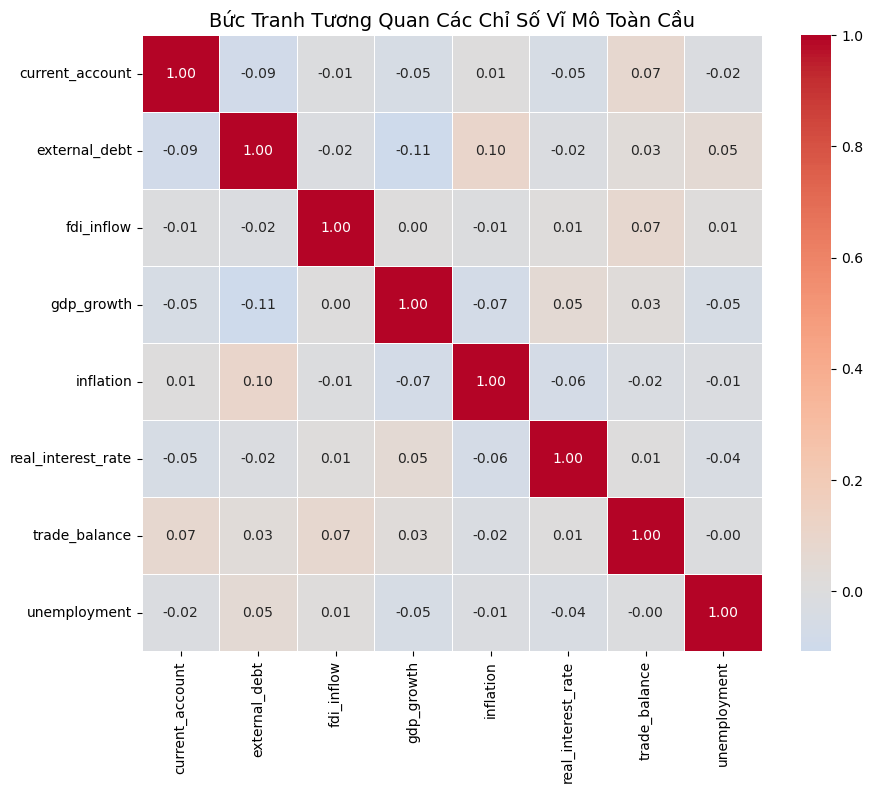

In [8]:
# !pip install seaborn 
import matplotlib.colors 
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.figure(figsize=(10,8))

corr_matrix = df_cleaned[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title("Bức Tranh Tương Quan Các Chỉ Số Vĩ Mô Toàn Cầu", fontsize=14)
plt.show()


### `Rút trích Insights`: 
- **Sự thật phũ phàng**: Nhìn vào heatmap, có thể thấy hầu hết các hệ số tương quan đều xoay quanh mức 0.00 đến 0.08. Điều này chứng tỏ không có mối quan hệ tuyến tính (linear) rõ ràng nào giữa 7 chỉ số cơ bản này.

- **Giá trị của AI Engineer**: Chính vì các chỉ số thô không có tương quan mạnh, nên nếu dùng một model đơn giản (như Linear Regression), nó sẽ thất bại thảm hại. Đây là minh chứng cho việc tại sao phải dùng các model phi tuyến tính phức tạp (như XGBoost, LightGBM) và phải thêm các đặc trưng mới (Feature Engineering) như Lag, Momentum để AI tìm ra các "pattern ẩn".

## Time Series Trend 

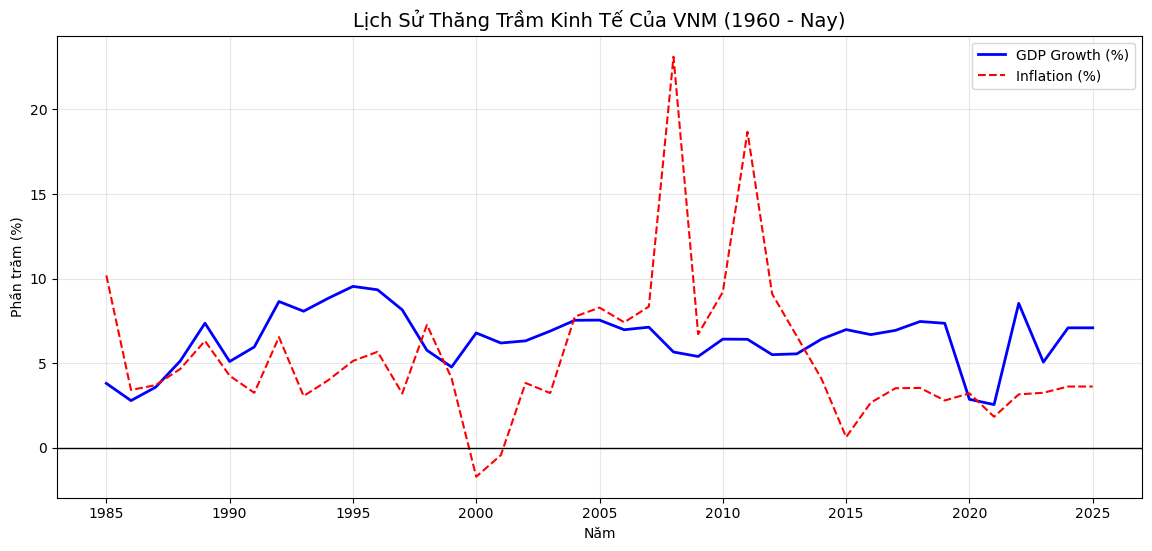

In [9]:
country_to_view = 'VNM'  
df_vnm = df_cleaned[df_cleaned['country_code'] == country_to_view]

plt.figure(figsize=(14, 6))

# Đường GDP Growth
plt.plot(df_vnm['year'], df_vnm['gdp_growth'], label='GDP Growth (%)', color='blue', linewidth=2)
# Đường Inflation
plt.plot(df_vnm['year'], df_vnm['inflation'], label='Inflation (%)', color='red', linestyle='--')

# Đánh dấu đường số 0
plt.axhline(0, color='black', linewidth=1)

plt.title(f"Lịch Sử Thăng Trầm Kinh Tế Của {country_to_view} (1960 - Nay)", fontsize=14)
plt.xlabel("Năm")
plt.ylabel("Phần trăm (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### `Rút trích Insights`: 

- Biểu đồ phản ánh cực kỳ chính xác lịch sử kinh tế Việt Nam cận đại.

- GDP (Đường xanh): Rơi thẳng đứng vào năm 2020 - 2021 do đại dịch COVID-19, và có một nhịp giảm nhẹ vào năm 1999 (ảnh hưởng muộn của Khủng hoảng Tài chính Châu Á 1997) và 2009 (Khủng hoảng Toàn cầu 2008).

- Lạm phát (Đường đỏ đứt nét): Có 2 đỉnh chóp cực kỳ đáng sợ vào năm 2008 (~23%) và 2011 (~19%). Bất kỳ ai sống qua giai đoạn này đều nhớ cảm giác giá cả leo thang phi mã. Sau năm 2012, đường lạm phát đi ngang và bám rất sát dưới mức 5%, cho thấy sự điều hành kinh tế vĩ mô của NHNN cực kỳ ổn định.

## Outliers / Distribution

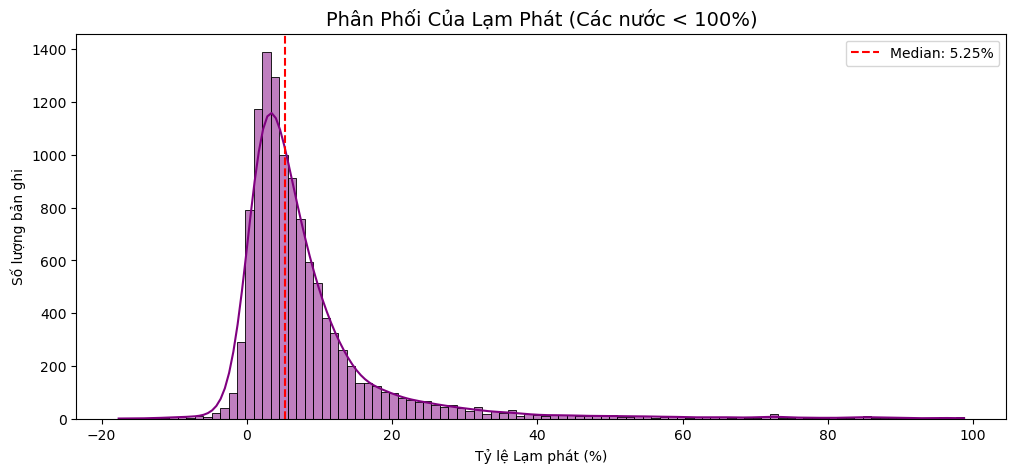

In [10]:
plt.figure(figsize=(12, 5))

# Vẽ biểu đồ phân phối của Lạm phát (Cắt bỏ những số quá lớn > 100% để dễ nhìn)
normal_inflation = df_cleaned[df_cleaned['inflation'] < 100]['inflation']

sns.histplot(normal_inflation, bins=100, kde=True, color='purple')
plt.title("Phân Phối Của Lạm Phát (Các nước < 100%)", fontsize=14)
plt.xlabel("Tỷ lệ Lạm phát (%)")
plt.ylabel("Số lượng bản ghi")
plt.axvline(normal_inflation.median(), color='red', linestyle='dashed', label=f'Median: {normal_inflation.median():.2f}%')
plt.legend()
plt.show()


###  `Insight:`

- Biểu đồ phân phối lệch phải (Right-skewed) cực kỳ nặng nề. Phần lớn thế giới có lạm phát gom tụ ở mức trung vị 5.13%.

- Tuy nhiên, phần "đuôi" (tail) kéo dài lê thê về bên phải (lên đến 100%) cho thấy thế giới luôn tồn tại những nền kinh tế rơi vào tình trạng "Siêu lạm phát" (Hyperinflation) như Argentina, Zimbabwe, hay Thổ Nhĩ Kỳ.

- Bài học MLOps: Khi đưa vào train model, sự phân phối lệch thế này sẽ làm model bị nhiễu. Ta sẽ cần áp dụng các phép biến đổi toán học như Log Transform hoặc dùng các mô hình dạng Cây (Tree-based models) vốn miễn nhiễm với outliers.

## Sự chuyển dịch cơ cấu qua các thập kỉ 

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24808\2608806949.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned[(df_cleaned['gdp_growth'] > -20) & (df_cleaned['gdp_growth'] < 20)],


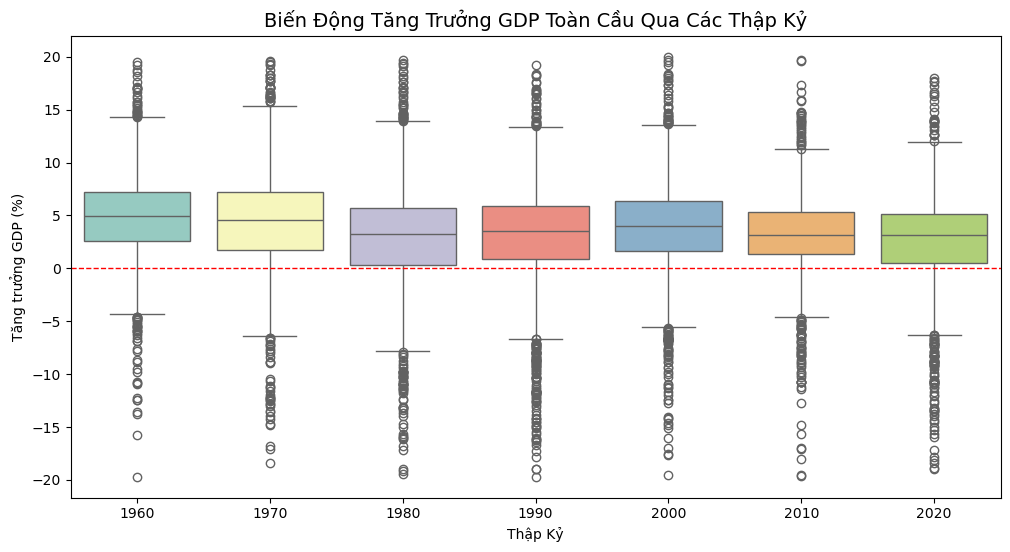

In [11]:
df_cleaned['decade'] = (df_cleaned['year'] // 10) * 10

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned[(df_cleaned['gdp_growth'] > -20) & (df_cleaned['gdp_growth'] < 20)], 
            x='decade', y='gdp_growth', palette='Set3')

plt.title("Biến Động Tăng Trưởng GDP Toàn Cầu Qua Các Thập Kỷ", fontsize=14)
plt.xlabel("Thập Kỷ")
plt.ylabel("Tăng trưởng GDP (%)")
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.show()


### `Insights:`

- **Kỷ nguyên vàng** của tăng trưởng kinh tế rơi vào thập niên 60 và 70. Từ thập niên 80 trở đi, đường trung vị (đường gạch ngang giữa hộp) đang nhích dần xuống, cho thấy rằng kinh tế thế giới đang bước vào giai đoạn tăng trưởng chậm lại 

## Dòng vốn FDI có mang lại sự Tăng trưởng? 

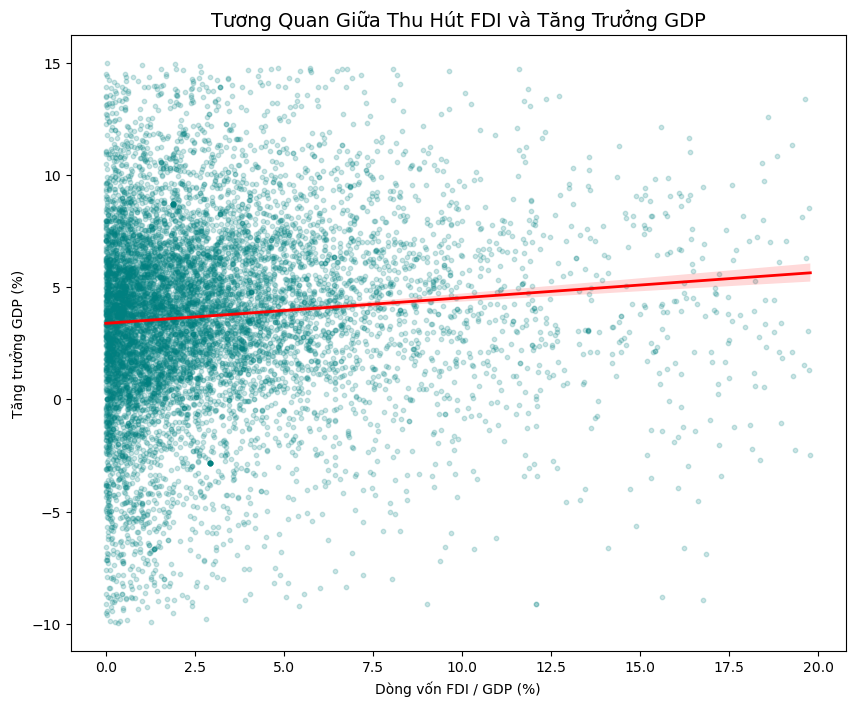

In [12]:
plt.figure(figsize=(10, 8))

# Lọc các outlier quá lố
df_fdi = df_cleaned[(df_cleaned['fdi_inflow'] > 0) & (df_cleaned['fdi_inflow'] < 20) & 
                    (df_cleaned['gdp_growth'] > -10) & (df_cleaned['gdp_growth'] < 15)]

# Vẽ Scatter plot kèm đường hồi quy tuyến tính (Regplot)
sns.regplot(data=df_fdi, x='fdi_inflow', y='gdp_growth', 
            scatter_kws={'alpha':0.2, 's':10, 'color':'teal'}, 
            line_kws={'color':'red', 'linewidth':2})

plt.title("Tương Quan Giữa Thu Hút FDI và Tăng Trưởng GDP", fontsize=14)
plt.xlabel("Dòng vốn FDI / GDP (%)")
plt.ylabel("Tăng trưởng GDP (%)")
plt.show()


### `Insights:`

- Đường màu đỏ hướng lên chứng minh FDI thực sự có ích cho tăng trưởng. Nhưng đám mây điểm tỏa ra quá rộng, cho thấy có những nước hút FDI rất nhiều nhưng GDP vẫn lẹt đẹt

## Feature Engineering

In [13]:
import numpy as np
import os

print("BẮT ĐẦU TẠO FEATURES (GOLD LAYER ULTIMATE)...")
df_features = df_cleaned.copy()

# sort lại thời gian 
df_features = df_features.sort_values(by=['country_code', 'year']).reset_index(drop=True)

# lấy các cột có kiểu numeric 
numeric_cols = [c for c in df_cleaned.columns if c not in ['country_code', 'country_name', 'year', 'decade']]

# lag + momentum 
print("  -> Đang tạo Lag & Momentum Features...")
for col in numeric_cols:
    df_features[f'{col}_lag1'] = df_features.groupby('country_code')[col].shift(1)
    df_features[f'{col}_lag2'] = df_features.groupby('country_code')[col].shift(2)

# Gia tốc (Sự thay đổi so với năm ngoái)
df_features['inflation_acceleration'] = df_features['inflation'] - df_features['inflation_lag1']
df_features['gdp_growth_change'] = df_features['gdp_growth'] - df_features['gdp_growth_lag1']

# trend 
print("  -> Đang tạo Volatility & Trend Features...")
for col in ['gdp_growth', 'inflation', 'fdi_inflow']:
    # Độ giật cục trong 3 năm (Volatility)
    df_features[f'{col}_volatility_3y'] = df_features.groupby('country_code')[col].transform(
        lambda x: x.rolling(window=3, min_periods=1).std()
    )
    # Trung bình 5 năm (SMA 5)
    df_features[f'{col}_sma5'] = df_features.groupby('country_code')[col].transform(
        lambda x: x.rolling(window=5, min_periods=1).mean()
    )
    # Độ lệch so với xu hướng dài hạn
    df_features[f'{col}_vs_trend'] = df_features[col] - df_features[f'{col}_sma5']

# các đặc trưng kinh tế chuyên sâu 
print("  -> Đang tạo Composite Indices...")
# Chỉ số Thống khổ (Misery Index = Lạm phát + Thất nghiệp)
if 'unemployment' in df_features.columns:
    df_features['misery_index'] = df_features['inflation'] + df_features['unemployment']

# Sự dễ vỡ bên ngoài (External Vulnerability = Cán cân vãng lai - FDI)
if 'current_account' in df_features.columns:
    df_features['external_vulnerability'] = df_features['current_account'] - df_features['fdi_inflow']

# z-score 
print("  -> Đang tạo Cross-country Z-Scores...")
# So sánh 1 nước với toàn bộ phần còn lại của thế giới trong CÙNG MỘT NĂM
df_features['gdp_global_zscore'] = df_features.groupby('year')['gdp_growth'].transform(
    lambda x: (x - x.mean()) / x.std()
)
df_features['inflation_global_zscore'] = df_features.groupby('year')['inflation'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# lưu vào feature.csv 
# xử lý các cột rỗng + clip để cắt về chuẩn 
df_features = df_features.dropna()
df_features['inflation_clipped'] = df_features['inflation'].clip(upper=100, lower=-10)

if 'fdi_inflow' in df_features.columns:
    df_features['fdi_inflow_clipped'] = df_features['fdi_inflow'].clip(upper=30, lower=-10)

# Lưu file CSV
GOLD_DIR = "../airflow/dags/data/gold"
os.makedirs(GOLD_DIR, exist_ok=True)
GOLD_CSV = os.path.join(GOLD_DIR, "feature_store.csv")
df_features.to_csv(GOLD_CSV, index=False)

print(f"\n✅ HOÀN TẤT! Dữ liệu đã phình to thành: {df_features.shape[1]} cột features.")
print(f"✅ Đã lưu Feature Store tại: {GOLD_CSV}")


BẮT ĐẦU TẠO FEATURES (GOLD LAYER ULTIMATE)...
  -> Đang tạo Lag & Momentum Features...
  -> Đang tạo Volatility & Trend Features...
  -> Đang tạo Composite Indices...
  -> Đang tạo Cross-country Z-Scores...

✅ HOÀN TẤT! Dữ liệu đã phình to thành: 45 cột features.
✅ Đã lưu Feature Store tại: ../airflow/dags/data/gold\feature_store.csv


## Lưu dữ liệu cho bước ML 

In [14]:
# ==================================================
# 2. TẠO THRESHOLD HỌC THUẬT (Dựa trên Quantile của Train)
# ==================================================
print("Đang tạo Nhãn Rủi ro Đa cấp độ (Composite Risk Score)...")

YEAR_VAL_START = 2011
YEAR_TEST_START = 2019

# ĐIỂM CHUẨN 1: Chỉ dùng train period để tính threshold, tránh leakage từ tương lai
train_period = df_features[df_features['year'] < YEAR_VAL_START]

gdp_thresh = train_period['gdp_growth'].quantile(0.10)              
inf_thresh = train_period['inflation_clipped'].quantile(0.90)       

# ĐIỂM CHUẨN 2: Xử lý mặc định an toàn về index
unemp_thresh = (
    train_period['unemployment'].quantile(0.90)
    if 'unemployment' in train_period.columns
    else 999
)

vul_thresh = (
    train_period['external_vulnerability'].quantile(0.10)
    if 'external_vulnerability' in train_period.columns
    else -999
)

print(f"Ngưỡng Tự động (Tính trên Train Period): \n - GDP < {gdp_thresh:.2f}%\n - Inflation > {inf_thresh:.2f}%")

cond_gdp = df_features['gdp_growth'] < gdp_thresh
cond_inf = df_features['inflation_clipped'] > inf_thresh

cond_unemp = (
    df_features['unemployment'] > unemp_thresh
    if 'unemployment' in df_features.columns
    else pd.Series(False, index=df_features.index)
)

cond_vul = (
    df_features['external_vulnerability'] < vul_thresh
    if 'external_vulnerability' in df_features.columns
    else pd.Series(False, index=df_features.index)
)

df_features['crisis_score'] = cond_gdp.astype(int) + cond_inf.astype(int) + cond_unemp.astype(int) + cond_vul.astype(int)

# ==================================================
# 3. QUY HOẠCH 3-CLASS & SHIFT TARGET (t+1)
# ==================================================
def categorize_risk(score):
    if score >= 2: return 2 # High
    if score == 1: return 1 # Medium
    return 0                # Low

df_features['risk_level'] = df_features['crisis_score'].apply(categorize_risk)

print("Đang Shift Target về năm t+1...")
df_features['target_risk_next_year'] = df_features.groupby('country_code')['risk_level'].shift(-1)

# Xóa những dòng không có tương lai
df_features = df_features.dropna(subset=['target_risk_next_year'])
df_features['target_risk_next_year'] = df_features['target_risk_next_year'].astype(int)

# ĐIỂM CHUẨN 3: Giữ nguyên base features (chỉ báo sớm năm T), chỉ drop biến score hiện tại
df_features = df_features.drop(columns=['crisis_score', 'risk_level'])

print("\nPhân phối Nhãn Đa Lớp (Toàn bộ Data T+1):")
print(df_features['target_risk_next_year'].value_counts())

# In thêm Crosstab và Value Counts chuẩn
print("\n--- Đánh giá độ ổn định của Label theo thời gian ---")
print(pd.crosstab(df_features['year'], df_features['target_risk_next_year']).tail(10))
print("\nPhân phối chuẩn hóa:")
print(df_features['target_risk_next_year'].value_counts(normalize=True))

# ==================================================
# 4. CHIA BÀI THEO THỜI GIAN VÀ LƯU FILE
# ==================================================
print("\nĐang chia tách Train / Val / Test...")

train_df = df_features[df_features['year'] < YEAR_VAL_START]
val_df = df_features[(df_features['year'] >= YEAR_VAL_START) & (df_features['year'] < YEAR_TEST_START)]
test_df = df_features[df_features['year'] >= YEAR_TEST_START]

ML_DATA_DIR = "../airflow/dags/data/ml_data"
os.makedirs(ML_DATA_DIR, exist_ok=True)

train_df.to_csv(f"{ML_DATA_DIR}/train.csv", index=False)
val_df.to_csv(f"{ML_DATA_DIR}/val.csv", index=False)
test_df.to_csv(f"{ML_DATA_DIR}/test.csv", index=False)

print(f"\n✅ Đã lưu Train ({len(train_df)} dòng): {ML_DATA_DIR}/train.csv")
print(f"✅ Đã lưu Val   ({len(val_df)} dòng): {ML_DATA_DIR}/val.csv")
print(f"✅ Đã lưu Test  ({len(test_df)} dòng): {ML_DATA_DIR}/test.csv")


Đang tạo Nhãn Rủi ro Đa cấp độ (Composite Risk Score)...
Ngưỡng Tự động (Tính trên Train Period): 
 - GDP < -2.16%
 - Inflation > 24.98%
Đang Shift Target về năm t+1...

Phân phối Nhãn Đa Lớp (Toàn bộ Data T+1):
target_risk_next_year
0    7607
1    3012
2     724
Name: count, dtype: int64

--- Đánh giá độ ổn định của Label theo thời gian ---
target_risk_next_year    0    1   2
year                               
2015                   155   44  15
2016                   151   46  17
2017                   159   47   9
2018                   161   42  11
2019                    63  100  51
2020                   151   56   7
2021                   148   57   8
2022                   151   49  10
2023                   154   42  11
2024                   139   37   6

Phân phối chuẩn hóa:
target_risk_next_year
0    0.670634
1    0.265538
2    0.063828
Name: proportion, dtype: float64

Đang chia tách Train / Val / Test...

✅ Đã lưu Train (8390 dòng): ../airflow/dags/data/ml_data/train.csv